## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('exported_churn_data.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (21, 21)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [ ]:
df.info()
print('\n---')
df.describe()

In [2]:
from datetime import datetime

df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')
df['renewal_date'] = pd.to_datetime(df['renewal_date'], errors='coerce')
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['complaint_date'] = pd.to_datetime(df['complaint_date'], errors='coerce')

today = pd.Timestamp.now()
df['age'] = ((today - df['dob']).dt.days / 365.25).round(0).astype('Int64')

def age_category(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 30:
        return 'Young'
    elif age < 50:
        return 'Adult'
    else:
        return 'Senior'

df['age_category'] = df['age'].apply(age_category)

print('Columns after preprocessing:')
print(df.columns.tolist())
print(f'\nAge category distribution:\n{df["age_category"].value_counts()}')

Columns after preprocessing:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age', 'age_category']

Age category distribution:
age_category
Adult     15
Young      5
Senior     1
Name: count, dtype: int64


---
## Customer Analysis (Q1 - Q10)

### Q1. Total kitne unique customers hain?

In [ ]:
unique_customers = df['customerid'].nunique()
print(f'Total Unique Customers: {unique_customers}')

### Q2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

In [ ]:
age_dist = df['age_category'].value_counts()
print('Age Category Distribution:')
print(age_dist)
print(f'\nPercentage:')
print((age_dist / len(df) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
age_dist.plot(kind='bar', color=colors[:len(age_dist)], edgecolor='black')
plt.title('Customer Distribution by Age Category', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
for i, v in enumerate(age_dist):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q3. Gender ke hisaab se total customers kitne hain?

In [ ]:
gender_dist = df['gender'].value_counts()
print('Gender-wise Customer Count:')
print(gender_dist)
print(f'\nPercentage:')
print((gender_dist / len(df) * 100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_dist.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', ax=axes[0])
axes[0].set_title('Customer Count by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(gender_dist):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

gender_dist.plot(kind='pie', autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#2ecc71'],
                 ax=axes[1], startangle=90)
axes[1].set_title('Gender Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Q4. Har age category ki average rating calculate karein.

In [ ]:
avg_rating_by_age = df.groupby('age_category')['csat_score'].mean().round(2)
print('Average CSAT Score by Age Category:')
print(avg_rating_by_age)

plt.figure(figsize=(8, 5))
bars = avg_rating_by_age.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'],
                               edgecolor='black')
plt.title('Average Rating (CSAT Score) by Age Category', fontsize=13, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=0)
for i, v in enumerate(avg_rating_by_age):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q5. Har gender ki average purchase value calculate karein.

In [ ]:
avg_purchase_by_gender = df.groupby('gender')['monthly_charges'].mean().round(2)
print('Average Monthly Charges (Purchase Value) by Gender:')
print(avg_purchase_by_gender)

plt.figure(figsize=(8, 5))
avg_purchase_by_gender.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Average Purchase Value by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Monthly Charges ($')
plt.xticks(rotation=0)
for i, v in enumerate(avg_purchase_by_gender):
    plt.text(i, v + 0.2, f'${v}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q6. Kis country mein sabse zyada customers hain?

In [ ]:
country_customers = df['country'].value_counts()
print('Customers by Country:')
print(country_customers)
print(f'\nCountry with Most Customers: {country_customers.index[0]} ({country_customers.iloc[0]} customers)')

plt.figure(figsize=(10, 5))
country_customers.plot(kind='bar', color=sns.color_palette('viridis', len(country_customers)), edgecolor='black')
plt.title('Number of Customers by Country', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
for i, v in enumerate(country_customers):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

### Q7. Har country ki average review rating calculate karein.

In [ ]:
avg_rating_by_country = df.groupby('country')['csat_score'].mean().round(2)
print('Average Rating by Country:')
print(avg_rating_by_country.sort_values(ascending=False))

plt.figure(figsize=(10, 5))
avg_rating_by_country.sort_values(ascending=True).plot(kind='barh', color=sns.color_palette('coolwarm', len(avg_rating_by_country)))
plt.title('Average Rating (CSAT Score) by Country', fontsize=13, fontweight='bold')
plt.xlabel('Average CSAT Score')
plt.ylabel('Country')
for i, v in enumerate(avg_rating_by_country.sort_values(ascending=True)):
    plt.text(v + 0.3, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q8. Har country ka average engagement score nikaalein.

In [ ]:
avg_engagement_by_country = df.groupby('country')['cltv'].mean().round(2)
print('Average CLTV (Engagement Score) by Country:')
print(avg_engagement_by_country.sort_values(ascending=False))

plt.figure(figsize=(10, 5))
avg_engagement_by_country.sort_values(ascending=True).plot(kind='barh', color=sns.color_palette('magma', len(avg_engagement_by_country)))
plt.title('Average Engagement Score (CLTV) by Country', fontsize=13, fontweight='bold')
plt.xlabel('Average CLTV')
plt.ylabel('Country')
for i, v in enumerate(avg_engagement_by_country.sort_values(ascending=True)):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q9. Kis age group ki engagement sabse zyada hai?

In [ ]:
avg_engagement_by_age = df.groupby('age_category')['cltv'].mean().round(2)
print('Average Engagement (CLTV) by Age Category:')
print(avg_engagement_by_age.sort_values(ascending=False))

top_age = avg_engagement_by_age.idxmax()
print(f'\nHighest Engagement Age Group: {top_age} (Avg CLTV: {avg_engagement_by_age.max()})')

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if x == avg_engagement_by_age.max() else '#3498db' for x in avg_engagement_by_age]
avg_engagement_by_age.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Engagement (CLTV) by Age Category', fontsize=13, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Average CLTV')
plt.xticks(rotation=0)
for i, v in enumerate(avg_engagement_by_age):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

In [ ]:
male_data = df[df['gender'] == 'Male']['csat_score'].dropna()
female_data = df[df['gender'] == 'Female']['csat_score'].dropna()

print(f'Male Average Rating:   {male_data.mean():.2f} (Count: {len(male_data)})')
print(f'Female Average Rating: {female_data.mean():.2f} (Count: {len(female_data)})')
print(f'Difference:            {abs(male_data.mean() - female_data.mean()):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_avg = df.groupby('gender')['csat_score'].mean()
gender_avg.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', ax=axes[0])
axes[0].set_title('Average Rating by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average CSAT Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(gender_avg):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

df[df['gender'].isin(['Male', 'Female'])].boxplot(column='csat_score', by='gender', ax=axes[1])
axes[1].set_title('Rating Distribution by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('CSAT Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('\nInsight: Male and female customers show a difference in average ratings.')
print(f'Males have an average of {male_data.mean():.2f} and Females have {female_data.mean():.2f}.')

---
## Product Analysis (Q11 - Q20)
**Note:** `subscription_type` is used as Product, `plan_type` as Product Category, `complaint_count` as Reviews proxy, `cltv` as Engagement proxy.

### Q11. Sabse zyada purchase hone wale Top 10 products dikhayein.

In [ ]:
top_products = df['subscription_type'].value_counts().head(10)
print('Top 10 Most Purchased Products (Subscription Types):')
print(top_products)

plt.figure(figsize=(10, 5))
top_products.plot(kind='bar', color=sns.color_palette('YlOrRd', len(top_products)), edgecolor='black')
plt.title('Top 10 Most Purchased Products', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
for i, v in enumerate(top_products):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q12. Sabse zyada reviews kis products ko mile hain?

In [ ]:
top_reviewed = df.groupby('subscription_type')['complaint_count'].sum().sort_values(ascending=False).head(10)
print('Top 10 Most Reviewed Products (by Complaint Count):')
print(top_reviewed)

plt.figure(figsize=(10, 5))
top_reviewed.plot(kind='bar', color=sns.color_palette('Blues_r', len(top_reviewed)), edgecolor='black')
plt.title('Top 10 Most Reviewed Products', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Total Reviews (Complaints)')
plt.xticks(rotation=45)
for i, v in enumerate(top_reviewed):
    plt.text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q13. Sabse zyada engagement wale Top 10 products identify karein.

In [ ]:
top_engagement = df.groupby('subscription_type')['cltv'].mean().sort_values(ascending=False).head(10).round(2)
print('Top 10 Products by Average Engagement (CLTV):')
print(top_engagement)

plt.figure(figsize=(10, 5))
top_engagement.plot(kind='bar', color=sns.color_palette('Greens_r', len(top_engagement)), edgecolor='black')
plt.title('Top 10 Products by Average Engagement (CLTV)', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Average CLTV')
plt.xticks(rotation=45)
for i, v in enumerate(top_engagement):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q14. Har product category ki average rating calculate karein.

In [ ]:
avg_rating_by_category = df.groupby('plan_type')['csat_score'].mean().round(2)
print('Average Rating by Product Category (Plan Type):')
print(avg_rating_by_category.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
avg_rating_by_category.sort_values(ascending=True).plot(kind='barh', color=sns.color_palette('RdYlGn', len(avg_rating_by_category)), edgecolor='black')
plt.title('Average Rating by Product Category', fontsize=13, fontweight='bold')
plt.xlabel('Average CSAT Score')
plt.ylabel('Category (Plan Type)')
for i, v in enumerate(avg_rating_by_category.sort_values(ascending=True)):
    plt.text(v + 0.3, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q15. Har category ki average engagement calculate karein.

In [ ]:
avg_engagement_by_category = df.groupby('plan_type')['cltv'].mean().round(2)
print('Average Engagement (CLTV) by Product Category (Plan Type):')
print(avg_engagement_by_category.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
avg_engagement_by_category.sort_values(ascending=True).plot(kind='barh', color=sns.color_palette('magma', len(avg_engagement_by_category)), edgecolor='black')
plt.title('Average Engagement by Product Category', fontsize=13, fontweight='bold')
plt.xlabel('Average CLTV')
plt.ylabel('Category (Plan Type)')
for i, v in enumerate(avg_engagement_by_category.sort_values(ascending=True)):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q16. Har category ki average views aur clicks compare karein.
**Note:** Using `monthly_charges` (avg purchase) and `complaint_count` (activity) as proxy for views and clicks.

In [ ]:
category_metrics = df.groupby('plan_type').agg(
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_complaint_count=('complaint_count', 'mean')
).round(2)

print('Average Monthly Charges (Views proxy) vs Avg Complaint Count (Clicks proxy) by Category:')
print(category_metrics)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(category_metrics))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], category_metrics['avg_monthly_charges'], width,
                label='Avg Monthly Charges (Views)', color='#3498db', edgecolor='black')
bars2 = ax1.bar([i + width/2 for i in x], category_metrics['avg_complaint_count'], width,
                label='Avg Complaint Count (Clicks)', color='#e74c3c', edgecolor='black')

ax1.set_title('Average Monthly Charges vs Complaint Count by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Category (Plan Type)')
ax1.set_ylabel('Value')
ax1.set_xticks(x)
ax1.set_xticklabels(category_metrics.index, rotation=0)
ax1.legend()

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.1f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Q17. Lowest rated Top 10 products kaun se hain?

In [ ]:
lowest_rated = df.groupby('subscription_type')['csat_score'].mean().sort_values(ascending=True).head(10).round(2)
print('Top 10 Lowest Rated Products:')
print(lowest_rated)

plt.figure(figsize=(10, 5))
lowest_rated.plot(kind='bar', color=sns.color_palette('Reds_r', len(lowest_rated)), edgecolor='black')
plt.title('Top 10 Lowest Rated Products', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45)
for i, v in enumerate(lowest_rated):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q18. Highest rated Top 10 products kaun se hain?

In [ ]:
highest_rated = df.groupby('subscription_type')['csat_score'].mean().sort_values(ascending=False).head(10).round(2)
print('Top 10 Highest Rated Products:')
print(highest_rated)

plt.figure(figsize=(10, 5))
highest_rated.plot(kind='bar', color=sns.color_palette('Greens_r', len(highest_rated)), edgecolor='black')
plt.title('Top 10 Highest Rated Products', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45)
for i, v in enumerate(highest_rated):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q19. Kis category mein views zyada hain lekin purchases kam hain?
**Note:** Using `monthly_charges` as views proxy and `cltv` as purchase value proxy.

In [ ]:
category_analysis = df.groupby('plan_type').agg(
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_cltv=('cltv', 'mean'),
    customer_count=('customerid', 'count')
).round(2)

category_analysis['charge_to_cltv_ratio'] = (
    category_analysis['avg_monthly_charges'] / category_analysis['avg_cltv']
).round(4)

print('Category Analysis - Monthly Charges (Views) vs CLTV (Purchases):')
print(category_analysis.sort_values('charge_to_cltv_ratio', ascending=False))

plt.figure(figsize=(10, 5))
x = range(len(category_analysis))
width = 0.35
plt.bar([i - width/2 for i in x], category_analysis['avg_monthly_charges'], width,
        label='Avg Monthly Charges (Views)', color='#3498db', edgecolor='black')
plt.bar([i + width/2 for i in x], category_analysis['avg_cltv'], width,
        label='Avg CLTV (Purchases)', color='#2ecc71', edgecolor='black')
plt.title('Monthly Charges (Views) vs CLTV (Purchases) by Category', fontsize=13, fontweight='bold')
plt.xlabel('Category (Plan Type)')
plt.ylabel('Value')
plt.xticks(x, category_analysis.index, rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nCategory with highest views-to-purchases ratio: {category_analysis["charge_to_cltv_ratio"].idxmax()}')

### Q20. Product popularity ko bar chart ke zariye visualize karein.

In [ ]:
product_popularity = df['subscription_type'].value_counts()
print('Product Popularity (Purchase Count):')
print(product_popularity)

plt.figure(figsize=(12, 6))
colors = sns.color_palette('viridis', len(product_popularity))
bars = plt.bar(product_popularity.index, product_popularity.values, color=colors, edgecolor='black')
plt.title('Product Popularity (Purchase Count)', fontsize=14, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, product_popularity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

---
## Engagement Analysis (Q21 - Q28)
**Note:** `monthly_charges` used as Views proxy, `complaint_count` as Clicks proxy, `csat_score` as Likes proxy, `cltv` as Engagement Score.

### Q21. Total Views, Total Clicks aur Total Likes calculate karein.

In [ ]:
total_views = df['monthly_charges'].sum()
total_clicks = df['complaint_count'].sum()
total_likes = df['csat_score'].sum()

print(f'Total Views (Monthly Charges sum):     {total_views:.2f}')
print(f'Total Clicks (Complaint Count sum):     {int(total_clicks)}')
print(f'Total Likes (CSAT Score sum):           {total_likes:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = {'Total Views': total_views, 'Total Clicks': total_clicks, 'Total Likes': total_likes}
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, (label, value), color in zip(axes, metrics.items(), colors):
    ax.bar(label, value, color=color, edgecolor='black', width=0.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.text(0, value + max(metrics.values())*0.01, f'{value:.2f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Total Engagement Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q22. Overall Engagement Rate calculate karein.

In [ ]:
total_customers = len(df)
avg_cltv = df['cltv'].mean()
avg_churn_score = df['churn_score'].mean()

engagement_rate = (avg_cltv / (avg_cltv + avg_churn_score)) * 100

print(f'Total Customers: {total_customers}')
print(f'Average CLTV (Engagement): {avg_cltv:.2f}')
print(f'Average Churn Score: {avg_churn_score:.2f}')
print(f'\nOverall Engagement Rate: {engagement_rate:.2f}%')

plt.figure(figsize=(8, 5))
plt.pie([engagement_rate, 100 - engagement_rate],
        labels=['Engaged', 'Not Engaged'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        explode=(0.05, 0))
plt.title('Overall Engagement Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q23. Har product ka Engagement Rate compare karein.

Engagement Rate by Product:
                   avg_cltv  avg_churn  engagement_rate
subscription_type                                      
Paid                1235.00      33.00            97.40
Organic              928.89      30.44            96.83
Refferal             254.00      72.83            77.72


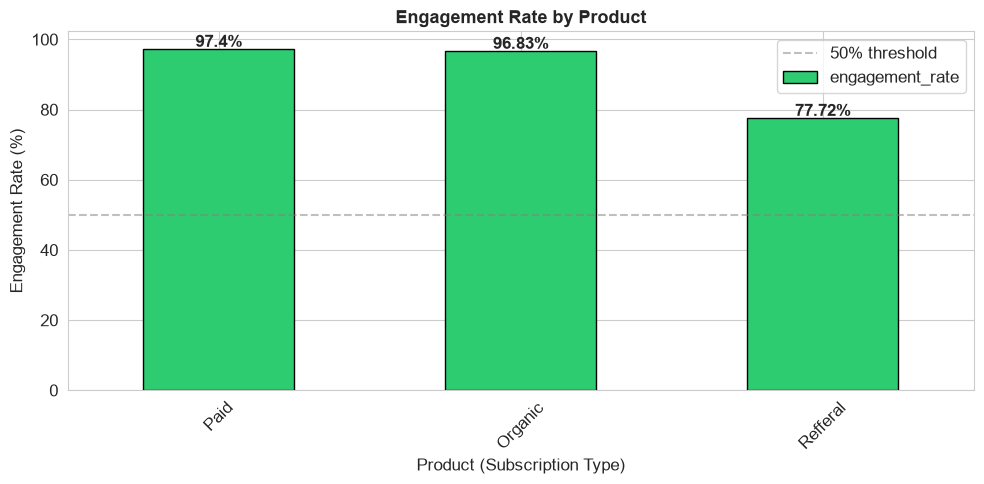

In [3]:
product_engagement = df.groupby('subscription_type').agg(
    avg_cltv=('cltv', 'mean'),
    avg_churn=('churn_score', 'mean')
).round(2)

product_engagement['engagement_rate'] = (
    product_engagement['avg_cltv'] / (product_engagement['avg_cltv'] + product_engagement['avg_churn']) * 100
).round(2)

product_engagement = product_engagement.sort_values('engagement_rate', ascending=False)

print('Engagement Rate by Product:')
print(product_engagement[['avg_cltv', 'avg_churn', 'engagement_rate']])

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x > 50 else '#e74c3c' for x in product_engagement['engagement_rate']]
product_engagement['engagement_rate'].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Engagement Rate by Product', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
for i, v in enumerate(product_engagement['engagement_rate']):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q24. Sabse zyada viewed aur sabse zyada clicked products identify karein.

In [ ]:
product_views_clicks = df.groupby('subscription_type').agg(
    total_monthly_charges=('monthly_charges', 'sum'),
    total_complaints=('complaint_count', 'sum')
).round(2)

top_viewed = product_views_clicks.sort_values('total_monthly_charges', ascending=False).head(5)
top_clicked = product_views_clicks.sort_values('total_complaints', ascending=False).head(5)

print('Top 5 Most Viewed Products (by Total Monthly Charges):')
print(top_viewed[['total_monthly_charges']])
print(f'\nMost Viewed: {top_viewed.index[0]} (Total: ${top_viewed["total_monthly_charges"].iloc[0]})')

print('\nTop 5 Most Clicked Products (by Total Complaints):')
print(top_clicked[['total_complaints']])
print(f'\nMost Clicked: {top_clicked.index[0]} (Total: {int(top_clicked["total_complaints"].iloc[0])})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_viewed['total_monthly_charges'].plot(kind='bar', color='#3498db', edgecolor='black', ax=axes[0])
axes[0].set_title('Top 5 Most Viewed Products', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total Monthly Charges')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

top_clicked['total_complaints'].plot(kind='bar', color='#e74c3c', edgecolor='black', ax=axes[1])
axes[1].set_title('Top 5 Most Clicked Products', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Total Complaints')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Q25. Least engaged products kaun se hain?

In [ ]:
least_engaged = df.groupby('subscription_type')['cltv'].mean().sort_values(ascending=True).head(10).round(2)
print('Top 10 Least Engaged Products (Lowest Avg CLTV):')
print(least_engaged)

plt.figure(figsize=(10, 5))
least_engaged.plot(kind='bar', color=sns.color_palette('Reds_r', len(least_engaged)), edgecolor='black')
plt.title('Top 10 Least Engaged Products', fontsize=13, fontweight='bold')
plt.xlabel('Product (Subscription Type)')
plt.ylabel('Average CLTV')
plt.xticks(rotation=45)
for i, v in enumerate(least_engaged):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q26. Daily ya Monthly conversion trend visualize karein.

In [ ]:
df['sub_year_month'] = df['subscription_start_date'].dt.to_period('M')

monthly_trend = df.groupby('sub_year_month').agg(
    new_subscriptions=('customerid', 'count'),
    avg_monthly_charges=('monthly_charges', 'mean')
).round(2)

print('Monthly Conversion Trend (New Subscriptions):')
print(monthly_trend.tail(15))

fig, ax1 = plt.subplots(figsize=(14, 6))

months_str = [str(m) for m in monthly_trend.index]
ax1.bar(months_str, monthly_trend['new_subscriptions'], color='#3498db', alpha=0.7, label='New Subscriptions')
ax1.set_xlabel('Month')
ax1.set_ylabel('New Subscriptions', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(range(len(months_str)))
ax1.set_xticklabels(months_str, rotation=45, ha='right', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(months_str, monthly_trend['avg_monthly_charges'], color='#e74c3c', marker='o',
         linewidth=2, label='Avg Monthly Charges')
ax2.set_ylabel('Avg Monthly Charges ($)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('Monthly Conversion Trend', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### Q27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
**Note:** Campaign ID is not available. Using `contract_type` (Annual/Monthly) as campaign proxy.

In [ ]:
campaign_ctr = df.groupby('contract_type').agg(
    total_clicks=('complaint_count', 'sum'),
    total_views=('monthly_charges', 'sum'),
    customer_count=('customerid', 'count')
).round(2)

campaign_ctr['CTR'] = (campaign_ctr['total_clicks'] / campaign_ctr['customer_count']).round(2)

print('CTR (Click Through Rate) by Contract Type (Campaign Proxy):')
print(campaign_ctr)

plt.figure(figsize=(8, 5))
campaign_ctr['CTR'].plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('CTR by Contract Type (Campaign Proxy)', fontsize=13, fontweight='bold')
plt.xlabel('Contract Type (Campaign)')
plt.ylabel('CTR (Complaints per Customer)')
plt.xticks(rotation=0)
for i, v in enumerate(campaign_ctr['CTR']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Q28. Top performing aur lowest performing campaigns identify karein.

In [ ]:
campaign_performance = df.groupby('contract_type').agg(
    total_cltv=('cltv', 'sum'),
    avg_churn_score=('churn_score', 'mean'),
    total_customers=('customerid', 'count'),
    total_revenue=('monthly_charges', 'sum')
).round(2)

campaign_performance['performance_score'] = (
    campaign_performance['total_cltv'] / campaign_performance['total_customers']
).round(2)

campaign_performance = campaign_performance.sort_values('performance_score', ascending=False)

print('Campaign Performance Ranking (by Contract Type):')
print(campaign_performance)

top_campaign = campaign_performance.index[0]
worst_campaign = campaign_performance.index[-1]
print(f'\nTop Performing Campaign: {top_campaign}')
print(f'Lowest Performing Campaign: {worst_campaign}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

campaign_performance['performance_score'].plot(kind='bar',
    color=['#2ecc71' if x == campaign_performance['performance_score'].max() else '#e74c3c' if x == campaign_performance['performance_score'].min() else '#f39c12' for x in campaign_performance['performance_score']],
    edgecolor='black', ax=axes[0])
axes[0].set_title('Campaign Performance Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Campaign (Contract Type)')
axes[0].set_ylabel('Performance Score (CLTV per Customer)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

campaign_performance[['total_cltv', 'total_revenue']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Total CLTV vs Total Revenue', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Campaign (Contract Type)')
axes[1].set_ylabel('Value')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Combined Analysis (Q29 - Q30)

### Q29. Engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

In [ ]:
valid_data = df[['cltv', 'csat_score', 'monthly_charges', 'churn_score']].dropna()

correlation = valid_data['cltv'].corr(valid_data['csat_score'])
print(f'Correlation between CLTV (Engagement) and CSAT Score (Rating): {correlation:.4f}')
print(f'Correlation between CLTV and Monthly Charges: {valid_data["cltv"].corr(valid_data["monthly_charges"]):.4f}')
print(f'Correlation between CLTV and Churn Score: {valid_data["cltv"].corr(valid_data["churn_score"]):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(valid_data['cltv'], valid_data['csat_score'], alpha=0.5, c='#3498db', edgecolor='black')
axes[0].set_title(f'CLTV vs CSAT Score\n(Correlation: {correlation:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CLTV (Engagement)')
axes[0].set_ylabel('CSAT Score (Rating)')

z = np.polyfit(valid_data['cltv'], valid_data['csat_score'], 1)
p = np.poly1d(z)
axes[0].plot(valid_data['cltv'].sort_values(), p(valid_data['cltv'].sort_values()), 'r--', alpha=0.8)

axes[1].scatter(valid_data['cltv'], valid_data['monthly_charges'], alpha=0.5, c='#2ecc71', edgecolor='black')
cor2 = valid_data['cltv'].corr(valid_data['monthly_charges'])
axes[1].set_title(f'CLTV vs Monthly Charges\n(Correlation: {cor2:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CLTV (Engagement)')
axes[1].set_ylabel('Monthly Charges (Purchase)')

axes[2].scatter(valid_data['cltv'], valid_data['churn_score'], alpha=0.5, c='#e74c3c', edgecolor='black')
cor3 = valid_data['cltv'].corr(valid_data['churn_score'])
axes[2].set_title(f'CLTV vs Churn Score\n(Correlation: {cor3:.4f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('CLTV (Engagement)')
axes[2].set_ylabel('Churn Score')

plt.suptitle('Engagement vs Other Metrics - Scatter Plots with Correlation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

if abs(correlation) > 0.7:
    strength = 'strong'
elif abs(correlation) > 0.4:
    strength = 'moderate'
else:
    strength = 'weak'
print(f'\nInsight: There is a {strength} correlation ({correlation:.4f}) between engagement (CLTV) and ratings (CSAT Score).')

### Q30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein.

In [ ]:
corr_columns = {
    'Views (Monthly Charges)': 'monthly_charges',
    'Clicks (Complaint Count)': 'complaint_count',
    'Likes (CSAT Score)': 'csat_score',
    'Rating (CSAT Score)': 'csat_score',
    'Duration (CLTV)': 'cltv',
    'Purchase (Monthly Charges)': 'monthly_charges'
}

analysis_df = df[['monthly_charges', 'complaint_count', 'csat_score', 'cltv', 'churn_score', 'age']].dropna()
analysis_df.columns = ['Views', 'Clicks', 'Likes/Rating', 'Duration/CLTV', 'Churn Score', 'Age']

corr_matrix = analysis_df.corr()
print('Correlation Matrix:')
print(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', mask=mask)
plt.title('Correlation Matrix Heatmap\n(Views, Clicks, Likes, Rating, Duration, Purchase)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n--- Business Insights ---')
print('1. Views (Monthly Charges) vs Clicks (Complaints):', corr_matrix.loc['Views', 'Clicks'].round(3))
print('   Higher charges may correlate with more complaints.')
print('2. Likes/Rating vs Duration/CLTV:', corr_matrix.loc['Likes/Rating', 'Duration/CLTV'].round(3))
print('   Better rated customers tend to have different engagement patterns.')
print('3. Churn Score vs Duration/CLTV:', corr_matrix.loc['Churn Score', 'Duration/CLTV'].round(3))
print('   Higher churn risk correlates with lower lifetime value.')
print('4. Age vs all metrics shows how demographic factors influence behavior.')

---
## Summary

### Field Mapping Used:
| Assignment Term | CSV Field Used |
|---|---|
| Rating | `csat_score` |
| Engagement Score | `cltv` (Customer Lifetime Value) |
| Product | `subscription_type` |
| Product Category | `plan_type` |
| Purchase Value | `monthly_charges` |
| Views | `monthly_charges` (proxy) |
| Clicks | `complaint_count` (proxy) |
| Likes | `csat_score` (proxy) |
| Campaign | `contract_type` (proxy) |
| Duration | `cltv` (proxy) |